# Nonzero altitude example

This notebook compares the output of Eradiate's Mitsuba and DISORT backends for a computation at nonzero altitude.

In [1]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg

import eradiate_disort as ed

eradiate.set_mode("ckd")
sns.set_theme(style="ticks")

In [2]:
ZENITHS = np.arange(-75.0, 76.0, 1.0)
SPP = 1_000
# CASES = {"0": 0.0, "1": 1.0, "5": 5.0, "10": 10.0}
CASES = {"0": 0.0, "50": 50.0}
# wmin, wmax = 300.0, 700.0
wmin, wmax = 600.0, 700.0


def make_exp(backend, wmin=590.0, wmax=610.0, tau_ref=0.0, altitude=0.0, spp=10_000):
    spp_radiance = max(spp // 16, 1)
    spp_flux = max(spp // (32 * 32 * 16), 1)
    srf = {"type": "uniform", "wmin": wmin, "wmax": wmax}
    angles = {"construct": "hplane", "azimuth": 30.0, "zeniths": [0.0]}
    measures = (
        [
            {
                "id": "toa_radiance",
                "type": "mdistant",
                **angles,
                "srf": srf,
                "spp": spp_radiance * 16,
            },
            {
                "id": "boa_flux",
                "type": "distantflux",
                "target": [1e-3, 1e-3, altitude] * ureg.km,
                "ray_offset": 1.0 * ureg.m,
                "film_resolution": (32, 32),
                "srf": srf,
                "spp": spp_flux * (32 * 32 * 16),
            },
        ]
        if backend == "mitsuba"
        else {"type": "disort", **angles, "srf": srf}
    )

    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 120.0 * ureg.km,
            "ground_altitude": altitude * ureg.km,
            "zgrid": np.arange(altitude, 121, 1) * ureg.km,
            # ground_altitude and zgrid lower bound must be identical
        },
        surface={"type": "lambertian", "reflectance": 0.5},
        atmosphere={
            "type": "heterogeneous",
            "molecular_atmosphere": {"absorption_data": "mycena"},
            # "particle_layers": particle_layer,
        },
        illumination={
            "type": "directional",
            "zenith": 30.0,
            "azimuth": 0.0,
        },
        measures=measures,
    )
    exp.integrator.moment = True

    return exp

In [3]:
results = {}

for case_id, altitude in CASES.items():
    print(f"Processing case {case_id!r}")
    exp_kwargs = {"altitude": altitude, "wmin": wmin, "wmax": wmax}

    exp_mitsuba = make_exp("mitsuba", **exp_kwargs)
    result_mitsuba = eradiate.run(exp_mitsuba, spp=1_000)

    exp_disort = make_exp("disort", **exp_kwargs)
    backend = ed.DisortBackend()
    result_disort = backend.run(exp_disort)

    # Extract irradiance
    irradiance = result_mitsuba["toa_radiance"]["irradiance"].squeeze()

    # Extract Mitsuba radiance
    radiance_mitsuba = result_mitsuba["toa_radiance"]["radiance"].squeeze()
    radiance_mitsuba_std = np.sqrt(
        result_mitsuba["toa_radiance"]["radiance_var"].squeeze()
    )

    # Compute Mitsuba BRF standard deviation
    brf_mitsuba = result_mitsuba["toa_radiance"]["brf"].squeeze()
    x = np.pi / result_mitsuba["toa_radiance"]["irradiance"]
    brf_mitsuba_std = np.sqrt(
        (result_mitsuba["toa_radiance"]["radiance_var"] * x**2).squeeze()
    )

    # Compute DISORT BRF
    radiance_disort = result_disort["measure"]["uu"].isel(z=0).squeeze()
    irradiance_disort = result_disort["measure"]["rfldir"].isel(z=0).squeeze()
    cos_theta_s = np.cos(exp_disort.illumination.zenith.m_as("rad"))
    brf_disort = radiance_disort / irradiance_disort * np.pi

    # Collect BOA flux (Mitsuba)
    boa_flux_mitsuba = result_mitsuba["boa_flux"]["radiosity"].squeeze()

    # Collect BOA flux (DISORT)
    boa_flux_disort = result_disort["measure"]["flup"].isel(z=-1).squeeze()

    results[case_id] = {
        "brf_mitsuba": brf_mitsuba,
        "brf_mitsuba_std": brf_mitsuba_std,
        "brf_disort": brf_disort,
        "boa_flux_mitsuba": boa_flux_mitsuba,
        "boa_flux_disort": boa_flux_disort,
    }

Processing case '0'


0/176|          | 00:00, ETA=?

0/176|          | 00:00, ETA=?

Processing case '50'


0/176|          | 00:00, ETA=?

0/176|          | 00:00, ETA=?

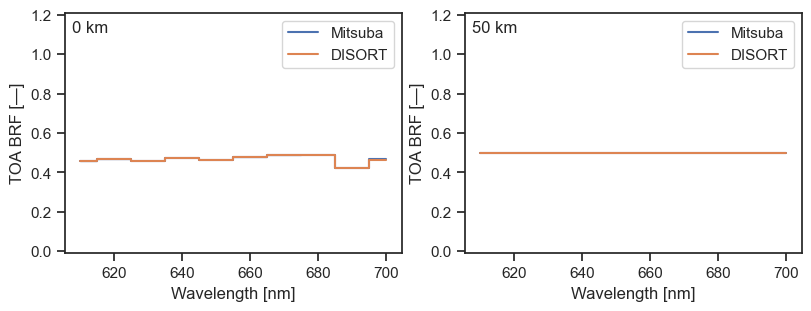

In [4]:
ncases = len(CASES)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 3 * nrows),
    layout="constrained",
    squeeze=False,
)

for i, case_id in enumerate(CASES.keys()):
    irow = i // ncols
    icol = i % ncols
    ax = axs.ravel()[i]
    brf_mitsuba = results[case_id]["brf_mitsuba"]
    brf_mitsuba_std = results[case_id]["brf_mitsuba_std"]
    brf_disort = results[case_id]["brf_disort"]

    x = brf_mitsuba["w"].values
    y = brf_mitsuba.values
    y_std = brf_mitsuba_std.values
    ymin = y - y_std * 2.0
    ymax = y + y_std * 2.0
    mask = (x >= wmin) & (x <= wmax)
    ax.step(x[mask], y[mask], where="mid", label="Mitsuba")
    ax.fill_between(x[mask], ymin[mask], ymax[mask], step="mid", alpha=0.25)

    x = brf_disort["w"].values
    y = brf_disort.values
    mask = (x >= wmin) & (x <= wmax)
    ax.step(x[mask], y[mask], where="mid", label="DISORT")

    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("TOA BRF [—]")
    ax.set_ylim(-0.01, 1.21)
    ax.legend()
    ax.set_title(f"{case_id} km", horizontalalignment="left", x=0.02, y=1.0, pad=-14)

plt.show()
plt.close()

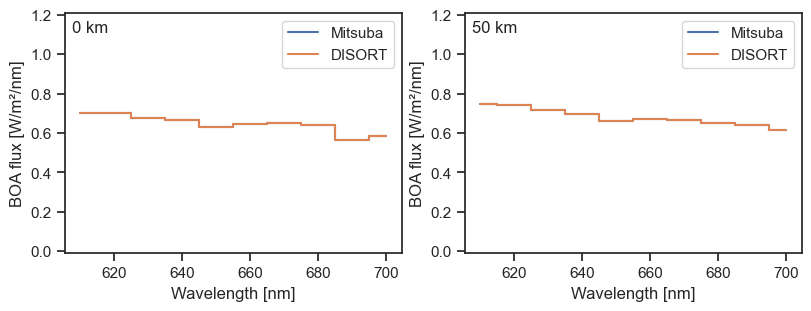

In [5]:
ncases = len(CASES)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 3 * nrows),
    layout="constrained",
    squeeze=False,
)

for i, case_id in enumerate(CASES.keys()):
    irow = i // ncols
    icol = i % ncols
    ax = axs.ravel()[i]
    flux_mitsuba = results[case_id]["boa_flux_mitsuba"]
    flux_disort = results[case_id]["boa_flux_disort"]

    x = flux_mitsuba["w"].values
    y = flux_mitsuba.values
    mask = (x >= wmin) & (x <= wmax)
    ax.step(x[mask], y[mask], where="mid", label="Mitsuba")

    x = flux_disort["w"].values
    y = flux_disort.values
    mask = (x >= wmin) & (x <= wmax)
    ax.step(x[mask], y[mask], where="mid", label="DISORT")

    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("BOA flux [W/m²/nm]")
    ax.set_ylim(-0.01, 1.21)
    ax.legend()
    ax.set_title(f"{case_id} km", horizontalalignment="left", x=0.02, y=1.0, pad=-14)

plt.show()
plt.close()